
# Dropout y Batch Normalization con datos simulados

En este notebook vamos a estudiar dos componentes muy usados en redes neuronales:

- **Dropout**
- **Batch Normalization**

pero sin imágenes y sin CNN.

La idea es usar un problema sintético 2D donde podamos **ver**:

1. qué ocurre con las activaciones;
2. qué cambia entre `model.train()` y `model.eval()`;
3. cómo aparece el overfitting;
4. cómo Dropout puede reducirlo;
5. qué efecto tiene BatchNorm sobre el entrenamiento;
6. qué ocurre cuando combinamos ambos.

---

## Una precisión importante

### Dropout

Sí es una técnica de **regularización**.

Su objetivo es reducir la dependencia excesiva entre neuronas y puede ayudar a disminuir el overfitting.

### Batch Normalization

No debe presentarse principalmente como una técnica anti-overfitting.

Su función principal es:

- estabilizar las activaciones;
- hacer más estable la optimización;
- permitir entrenamientos más robustos;
- reducir la sensibilidad a la escala de las activaciones.

Puede tener un **efecto regularizador secundario**, porque durante training usa estadísticas del batch, pero ese no es su propósito principal.

Por eso compararemos:

```text
Baseline
Dropout
BatchNorm
BatchNorm + Dropout
```


In [1]:

import copy
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cpu



# 1. Dataset sintético

Usaremos `make_moons`.

Es un problema de clasificación binaria no lineal:

```text
clase 0  ☾
clase 1    ☽
```

Para hacer el experimento interesante:

- usaremos **pocos datos de entrenamiento**;
- agregaremos ruido;
- construiremos una red con mucha más capacidad de la necesaria.

Eso hará relativamente fácil que aparezca overfitting.


In [2]:

X, y = make_moons(
    n_samples=1400,
    noise=0.28,
    random_state=SEED,
)

# Primero separamos un test grande.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.50,
    random_state=SEED,
    stratify=y,
)

# De train_full nos quedamos deliberadamente con pocos ejemplos.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    train_size=180,
    random_state=SEED,
    stratify=y_train_full,
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))


Train: 180
Validation: 520
Test: 700


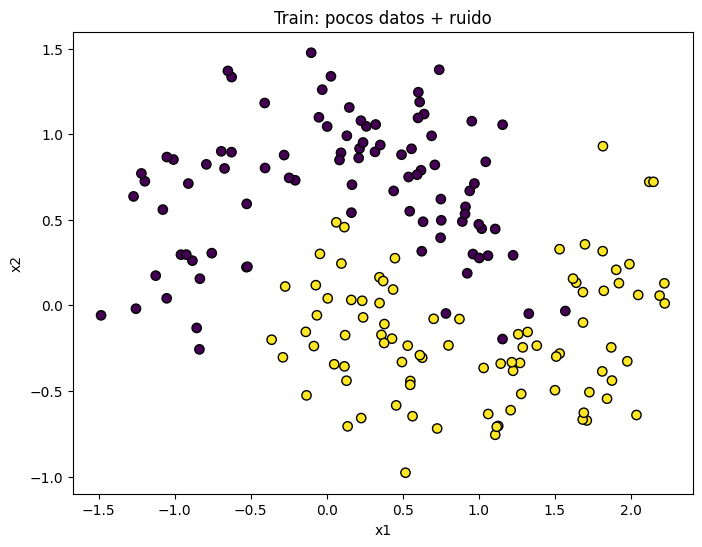

In [3]:

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    s=45,
    edgecolor="black",
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Train: pocos datos + ruido")
plt.grid(False)
plt.show()



# 2. Estandarización

Aplicamos `StandardScaler` usando **solo train**.

Luego usamos esa misma transformación sobre validation y test.


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)


In [5]:

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
)



# 3. Primero: ¿qué hace Dropout?

Supongamos que una capa produce estas activaciones:

```text
[1, 1, 1, 1, 1, 1, 1, 1]
```

Con:

```python
nn.Dropout(p=0.5)
```

durante training algunas activaciones se apagan aleatoriamente.

PyTorch además escala las que sobreviven para conservar aproximadamente el valor esperado.


In [6]:

drop = nn.Dropout(p=0.5)

x_demo = torch.ones(12)

drop.train()

print("TRAIN")
for _ in range(4):
    print(drop(x_demo))

drop.eval()

print("\nEVAL")
for _ in range(4):
    print(drop(x_demo))


TRAIN
tensor([2., 2., 2., 2., 0., 2., 0., 0., 2., 2., 2., 2.])
tensor([0., 0., 2., 0., 2., 0., 0., 2., 2., 0., 2., 2.])
tensor([2., 2., 0., 2., 2., 2., 2., 2., 2., 2., 0., 0.])
tensor([0., 2., 2., 2., 0., 2., 2., 2., 0., 0., 2., 2.])

EVAL
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])



## ¿Qué observamos?

En:

```python
model.train()
```

la salida cambia en cada forward pass.

En:

```python
model.eval()
```

Dropout deja de apagar unidades.

Esto es fundamental:

```text
TRAIN
activaciones
    ↓
máscara aleatoria
    ↓
algunas neuronas quedan apagadas

EVAL
activaciones
    ↓
sin máscara
    ↓
todas las neuronas participan
```

Dropout tiene:

$$
\boxed{0\text{ parámetros aprendibles}}
$$



# 4. ¿Qué hace BatchNorm?

Para una capa completamente conectada usamos:

```python
nn.BatchNorm1d(D)
```

donde $D$ es el número de características de la capa.

Durante training, para cada feature:

$$
\hat{x}
=
\frac{x-\mu_B}
{\sqrt{\sigma_B^2+\epsilon}}
$$

y después:

$$
y
=
\gamma\hat{x}+\beta
$$

donde:

- $\mu_B$: media del batch;
- $\sigma_B^2$: varianza del batch;
- $\gamma$: escala aprendible;
- $\beta$: desplazamiento aprendible.


In [7]:
bn = nn.BatchNorm1d(4)

x_bn = torch.tensor([
    [ 2., 10., 100., -5.],
    [ 4., 12., 120., -3.],
    [ 6., 14., 140., -1.],
    [ 8., 16., 160.,  1.],
    [10., 18., 180.,  3.],
])

bn.train()
z_bn = bn(x_bn)

print("INPUT")
print(x_bn)

print("\nBATCHNORM OUTPUT")
print(z_bn.detach())

print("\nMean por feature:")
print(z_bn.detach().mean(dim=0))

print("\nVariance por feature:")
print(z_bn.detach().var(dim=0, unbiased=False))


INPUT
tensor([[  2.,  10., 100.,  -5.],
        [  4.,  12., 120.,  -3.],
        [  6.,  14., 140.,  -1.],
        [  8.,  16., 160.,   1.],
        [ 10.,  18., 180.,   3.]])

BATCHNORM OUTPUT
tensor([[-1.4142e+00, -1.4142e+00, -1.4142e+00, -1.4142e+00],
        [-7.0711e-01, -7.0711e-01, -7.0711e-01, -7.0711e-01],
        [ 0.0000e+00,  2.3842e-07,  1.3411e-07,  0.0000e+00],
        [ 7.0711e-01,  7.0711e-01,  7.0711e-01,  7.0711e-01],
        [ 1.4142e+00,  1.4142e+00,  1.4142e+00,  1.4142e+00]])

Mean por feature:
tensor([0.0000e+00, 2.3842e-07, 1.4305e-07, 0.0000e+00])

Variance por feature:
tensor([1.0000, 1.0000, 1.0000, 1.0000])



BatchNorm aprende además:

```text
gamma
beta
```

Para `BatchNorm1d(4)`:

```text
gamma → 4 parámetros
beta  → 4 parámetros
```

por tanto:

\[
8
\]

parámetros aprendibles.

También mantiene:

```text
running_mean
running_var
```

que **no son parámetros optimizados por gradiente**, sino estadísticas acumuladas.


In [8]:

print("Parámetros aprendibles:")
for name, parameter in bn.named_parameters():
    print(name, parameter.detach())

print("\nBuffers:")
for name, buffer in bn.named_buffers():
    print(name, buffer)


Parámetros aprendibles:
weight tensor([1., 1., 1., 1.])
bias tensor([0., 0., 0., 0.])

Buffers:
running_mean tensor([ 0.6000,  1.4000, 14.0000, -0.1000])
running_var tensor([  1.9000,   1.9000, 100.9000,   1.9000])
num_batches_tracked tensor(1)



# 5. `train()` vs `eval()` en BatchNorm

Durante training:

```python
model.train()
```

BatchNorm usa estadísticas del **batch actual** y actualiza sus estadísticas móviles.

Durante evaluación:

```python
model.eval()
```

usa:

```text
running_mean
running_var
```

acumuladas durante training.

Por eso `model.eval()` no significa únicamente "no calcular gradientes".

De hecho:

```python
torch.no_grad()
```

y:

```python
model.eval()
```

resuelven problemas diferentes.


In [9]:

small_batch = torch.tensor([
    [50., 2., -8., 20.],
    [60., 4., -6., 40.],
])

bn.train()
out_train = bn(small_batch)

bn.eval()
out_eval = bn(small_batch)

print("TRAIN:")
print(out_train.detach())

print("\nEVAL:")
print(out_eval.detach())


TRAIN:
tensor([[-1.0000, -1.0000, -1.0000, -1.0000],
        [ 1.0000,  1.0000,  1.0000,  1.0000]])

EVAL:
tensor([[16.9706,  0.3184, -2.0860,  3.6679],
        [20.8310,  1.7655, -1.8763,  7.9603]])



# 6. Una MLP deliberadamente demasiado grande

Nuestro problema tiene:

```text
2 variables de entrada
180 ejemplos de entrenamiento
```

pero construiremos una red con varias capas ocultas grandes.

Eso genera una situación favorable para observar overfitting.

El bloque típico será:

```text
Linear
  ↓
BatchNorm opcional
  ↓
ReLU
  ↓
Dropout opcional
```


In [10]:

class MLP(nn.Module):
    def __init__(
        self,
        use_batchnorm=False,
        dropout_p=0.0,
    ):
        super().__init__()

        layers = []

        dims = [2, 128, 128, 128, 64]

        for in_dim, out_dim in zip(dims[:-1], dims[1:]):
            layers.append(
                nn.Linear(in_dim, out_dim)
            )

            if use_batchnorm:
                layers.append(
                    nn.BatchNorm1d(out_dim)
                )

            layers.append(
                nn.ReLU()
            )

            if dropout_p > 0:
                layers.append(
                    nn.Dropout(dropout_p)
                )

        layers.append(
            nn.Linear(dims[-1], 2)
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)



# 7. Cuatro modelos

Compararemos:

```text
A. Baseline
B. Dropout
C. BatchNorm
D. BatchNorm + Dropout
```

Mantendremos constante:

- arquitectura base;
- dataset;
- optimizador;
- learning rate;
- número de épocas.

Así podemos comparar los efectos de cada componente.


In [11]:

def build_models():
    torch.manual_seed(SEED)

    return {
        "Baseline": MLP(
            use_batchnorm=False,
            dropout_p=0.0,
        ),
        "Dropout": MLP(
            use_batchnorm=False,
            dropout_p=0.40,
        ),
        "BatchNorm": MLP(
            use_batchnorm=True,
            dropout_p=0.0,
        ),
        "BatchNorm + Dropout": MLP(
            use_batchnorm=True,
            dropout_p=0.40,
        ),
    }


models = build_models()

for name, model in models.items():
    n_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(f"{name:20s}: {n_params:,} parámetros")


Baseline            : 41,794 parámetros
Dropout             : 41,794 parámetros
BatchNorm           : 42,690 parámetros
BatchNorm + Dropout : 42,690 parámetros



Observa:

- **Dropout no agrega parámetros**.
- **BatchNorm sí agrega parámetros**: \(\gamma\) y \(\beta\).



# 8. Training loop

Vamos a registrar:

- train loss;
- validation loss;
- train accuracy;
- validation accuracy.

La señal clásica de overfitting será algo parecido a:

```text
train loss ↓↓↓
train accuracy ↑↑↑

pero

validation loss ↑
validation accuracy deja de mejorar
```


In [12]:

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * len(y)
        total_correct += (
            logits.argmax(dim=1) == y
        ).sum().item()
        total += len(y)

    return (
        total_loss / total,
        total_correct / total,
    )


def train_model(model, epochs=250, lr=1e-3):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    for epoch in range(epochs):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(x)
            loss = criterion(logits, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y)
            total_correct += (
                logits.argmax(dim=1) == y
            ).sum().item()
            total += len(y)

        train_loss = total_loss / total
        train_acc = total_correct / total

        val_loss, val_acc = evaluate(
            model,
            val_loader,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return model, history



# 9. Entrenemos los cuatro modelos

Este experimento está diseñado para hacer visible el **gap train-validation**.

No esperamos necesariamente que todos los runs tengan exactamente el mismo comportamiento.

La aleatoriedad también es parte del entrenamiento de redes neuronales.


In [13]:

trained_models = {}
histories = {}

for name, model in build_models().items():
    print("Training:", name)

    trained_model, history = train_model(
        model,
        epochs=250,
        lr=1e-3,
    )

    trained_models[name] = trained_model
    histories[name] = history


Training: Baseline
Training: Dropout
Training: BatchNorm
Training: BatchNorm + Dropout



# 10. Loss: ¿dónde aparece el overfitting?

Primero observemos train y validation loss para cada modelo.


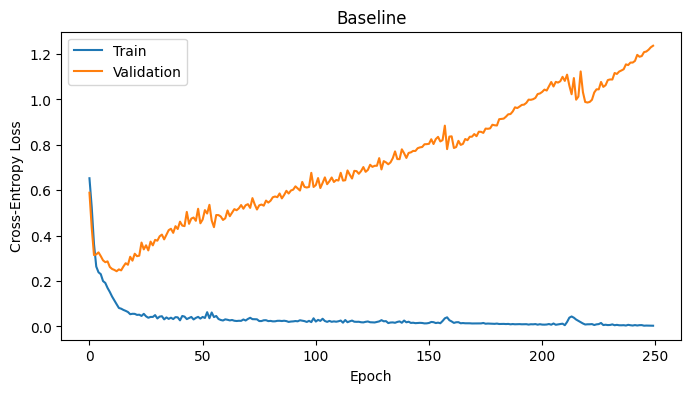

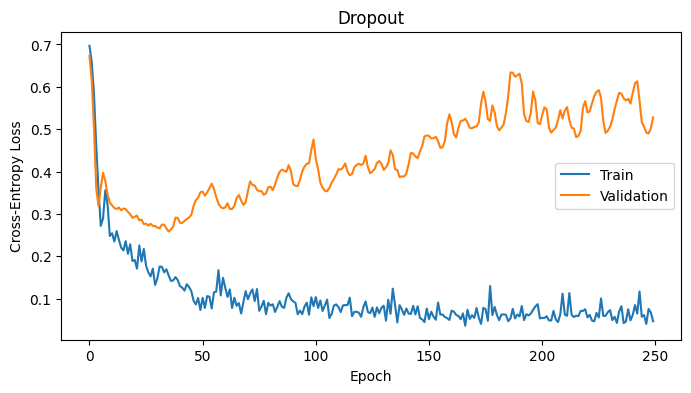

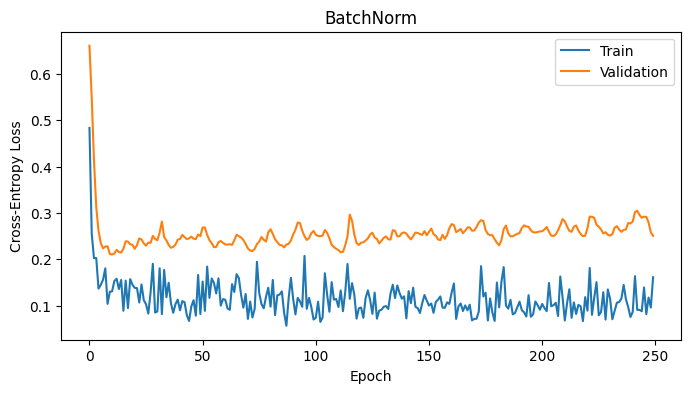

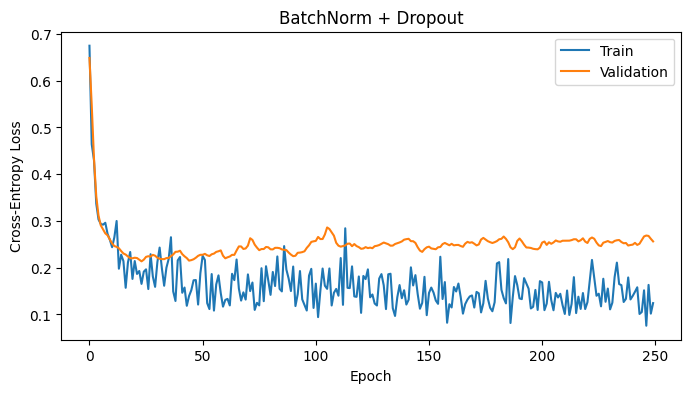

In [14]:

for name, history in histories.items():
    plt.figure(figsize=(8, 4))

    plt.plot(
        history["train_loss"],
        label="Train",
    )

    plt.plot(
        history["val_loss"],
        label="Validation",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title(name)
    plt.legend()
    plt.grid(False)
    plt.show()



## ¿Qué buscar?

Un patrón típico de overfitting es:

```text
Train loss
    ↓
sigue disminuyendo

Validation loss
    ↓ inicialmente
    ↑ después
```

Eso significa que el modelo sigue adaptándose cada vez mejor a train, pero su capacidad de generalizar empeora.



# 11. Accuracy: train vs validation

Ahora observemos el **generalization gap**:

\[
\text{gap}
=
\text{train accuracy}
-
\text{validation accuracy}
\]


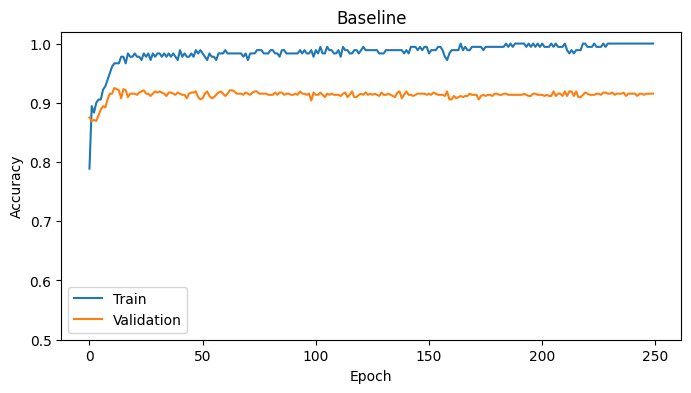

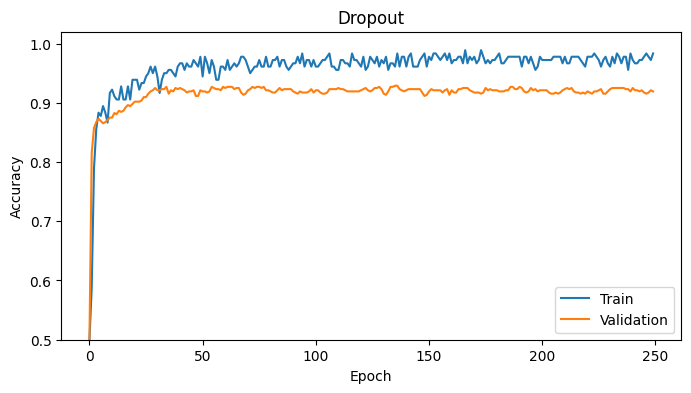

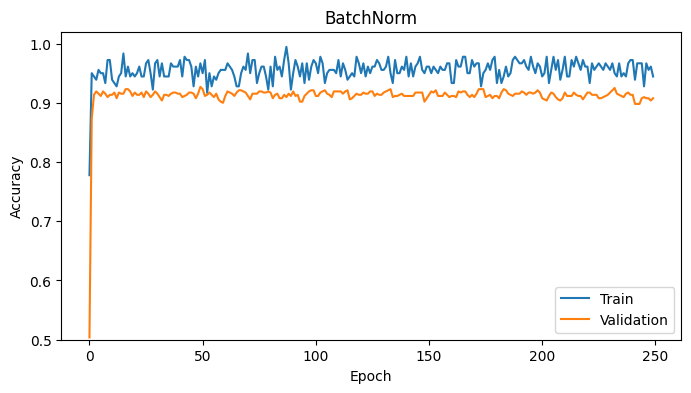

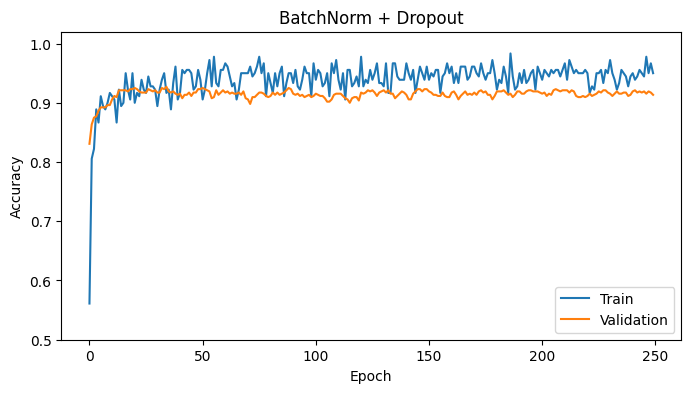

In [15]:

for name, history in histories.items():
    plt.figure(figsize=(8, 4))

    plt.plot(
        history["train_acc"],
        label="Train",
    )

    plt.plot(
        history["val_acc"],
        label="Validation",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(name)
    plt.ylim(0.5, 1.02)
    plt.legend()
    plt.grid(False)
    plt.show()



# 12. Resumen numérico

Para cada modelo calcularemos:

- máxima validation accuracy;
- época donde ocurrió;
- train accuracy en esa época;
- gap train-validation;
- test accuracy final del modelo correspondiente a la mejor época de validation.

Para hacerlo correctamente necesitaríamos guardar checkpoints durante el entrenamiento.

En este notebook usaremos la historia para analizar el comportamiento y el modelo final para visualizar fronteras de decisión.


In [16]:

rows = []

for name, history in histories.items():
    best_epoch = int(
        np.argmax(history["val_acc"])
    )

    rows.append({
        "model": name,
        "best_epoch": best_epoch + 1,
        "train_acc_at_best": history["train_acc"][best_epoch],
        "best_val_acc": history["val_acc"][best_epoch],
        "gap_at_best": (
            history["train_acc"][best_epoch]
            - history["val_acc"][best_epoch]
        ),
        "final_train_acc": history["train_acc"][-1],
        "final_val_acc": history["val_acc"][-1],
    })

import pandas as pd

results = pd.DataFrame(rows)
results


,model,best_epoch,train_acc_at_best,best_val_acc,gap_at_best,final_train_acc,final_val_acc
0,Baseline,12,0.966667,0.925000,0.041667,1.000000,0.915385
1,Dropout,136,0.961111,0.928846,0.032265,0.983333,0.919231
2,BatchNorm,50,0.966667,0.926923,0.039744,0.944444,0.907692
3,BatchNorm + Dropout,35,0.916667,0.926923,-0.010256,0.950000,0.913462



# 13. Fronteras de decisión

Como el problema tiene solo dos variables, podemos visualizar qué función aprendió cada red.

Una frontera demasiado irregular puede ser una señal visual de que el modelo está ajustándose al ruido de train.


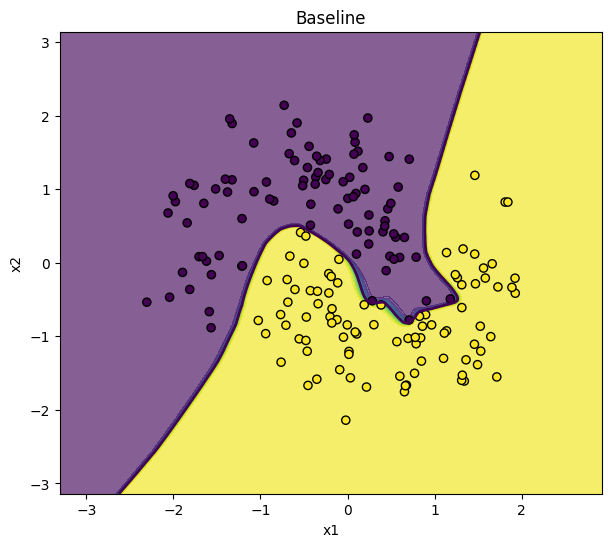

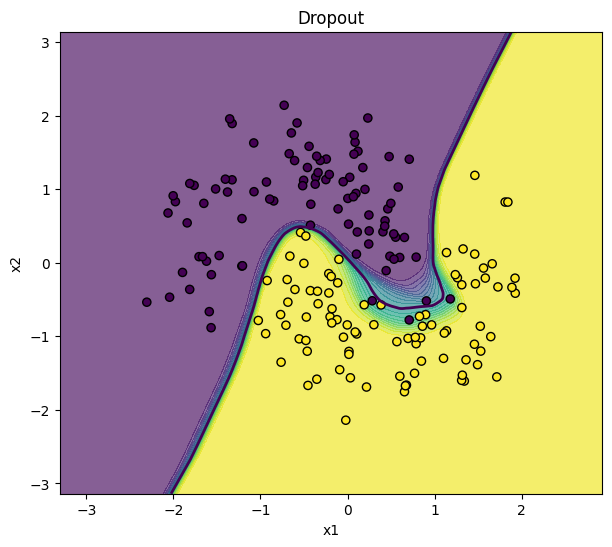

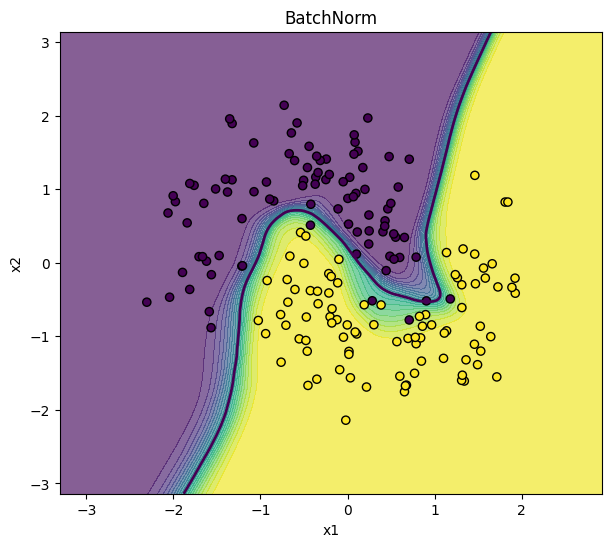

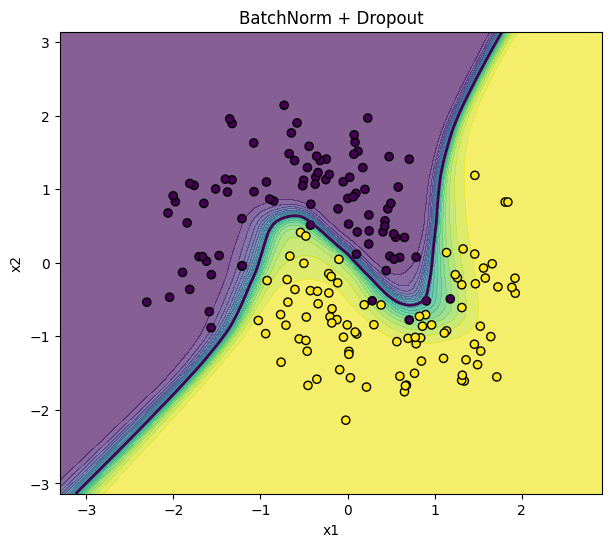

In [17]:

def plot_decision_boundary(model, title):
    model.eval()

    x_min, x_max = (
        X_train_scaled[:, 0].min() - 1.0,
        X_train_scaled[:, 0].max() + 1.0,
    )

    y_min, y_max = (
        X_train_scaled[:, 1].min() - 1.0,
        X_train_scaled[:, 1].max() + 1.0,
    )

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel(),
    ]

    grid_t = torch.tensor(
        grid,
        dtype=torch.float32,
        device=device,
    )

    with torch.no_grad():
        probs = torch.softmax(
            model(grid_t),
            dim=1,
        )[:, 1]

    zz = probs.cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(7, 6))

    plt.contourf(
        xx,
        yy,
        zz,
        levels=20,
        alpha=0.65,
    )

    plt.scatter(
        X_train_scaled[:, 0],
        X_train_scaled[:, 1],
        c=y_train,
        edgecolor="black",
        s=35,
    )

    plt.contour(
        xx,
        yy,
        zz,
        levels=[0.5],
        linewidths=2,
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(False)
    plt.show()


for name, model in trained_models.items():
    plot_decision_boundary(
        model,
        name,
    )



# 14. ¿Qué debemos concluir sobre Dropout?

Dropout introduce ruido estructurado durante training:

```text
red completa
    ↓
apagar aleatoriamente unidades
    ↓
la red no puede depender siempre
de las mismas neuronas
```

Una intuición útil es que cada mini-batch entrena una subred ligeramente diferente.

Esto puede reducir la co-adaptación excesiva de neuronas y dificultar que la red simplemente memorice train.

Por eso suele ocurrir:

```text
training accuracy con Dropout
<
training accuracy sin Dropout
```

pero validation puede mejorar.

Esto no es un error.

Es precisamente el tipo de comportamiento que esperamos de una técnica de regularización.



# 15. ¿Qué debemos concluir sobre BatchNorm?

BatchNorm cambia la dinámica de entrenamiento.

Puede:

- estabilizar activaciones;
- mejorar el flujo de gradientes;
- hacer la optimización menos sensible a ciertas escalas;
- permitir convergencia más estable.

Además, durante training las estadísticas dependen del batch:

```text
batch 1 → μ1, σ1
batch 2 → μ2, σ2
batch 3 → μ3, σ3
```

Esto introduce cierta variabilidad y puede generar un efecto regularizador.

Pero conceptualmente:

> **No deberíamos enseñar BatchNorm como una técnica diseñada principalmente para evitar overfitting.**

Dropout y BatchNorm resuelven problemas diferentes.



# 16. Comparación conceptual

| Componente | ¿Tiene parámetros? | Cambia en train/eval | Objetivo principal |
|---|---:|---:|---|
| `Linear` | Sí | No | aprender transformación |
| `ReLU` | No | No | introducir no linealidad |
| `Dropout` | No | Sí | regularización |
| `BatchNorm` | Sí: \(\gamma,\beta\) | Sí | estabilizar/normalizar activaciones |

---

Un bloque típico:

```text
Linear
  ↓
BatchNorm
  ↓
ReLU
  ↓
Dropout
```

combina cuatro funciones diferentes:

```text
Linear
aprende representación

BatchNorm
estabiliza activaciones

ReLU
introduce no linealidad

Dropout
regulariza
```



# 17. Experimento opcional: intensidad de Dropout

Prueba:

```text
p = 0.0
p = 0.2
p = 0.5
p = 0.8
```

y analiza:

- train accuracy;
- validation accuracy;
- gap;
- velocidad de convergencia.

## Pregunta

¿Más Dropout siempre es mejor?

No.

Si apagamos demasiada capacidad, podemos pasar de:

```text
overfitting
```

a:

```text
underfitting
```

La regularización también es un hiperparámetro.


In [18]:

# TODO
# Experimenta con distintos valores de dropout_p.

# dropout_values = [0.0, 0.2, 0.5, 0.8]
#
# for p in dropout_values:
#     model = MLP(
#         use_batchnorm=False,
#         dropout_p=p,
#     )
#
#     model, history = train_model(
#         model,
#         epochs=250,
#         lr=1e-3,
#     )
#
#     ...



# 18. Preguntas para discusión

### 1

¿Por qué Dropout produce resultados diferentes si pasamos exactamente el mismo ejemplo varias veces durante training?

### 2

¿Por qué deja de hacerlo en evaluation?

### 3

¿Dropout tiene parámetros aprendibles?

### 4

¿Qué parámetros aprende BatchNorm?

### 5

¿Qué diferencia existe entre:

```python
model.eval()
```

y:

```python
torch.no_grad()
```

?

### 6

¿Qué patrón en las curvas train/validation indica overfitting?

### 7

¿Por qué un modelo con Dropout puede tener menor training accuracy pero mejor validation accuracy?

### 8

¿Podemos afirmar que BatchNorm siempre reduce overfitting?

### 9

¿Qué podría ocurrir con un Dropout excesivamente alto?

### 10

¿Por qué BatchNorm puede comportarse mal con batches extremadamente pequeños?



# Conclusión

Los dos componentes se parecen superficialmente porque aparecen entre capas de una red, pero cumplen roles diferentes.

## Dropout

\[
\boxed{
\text{regularización}
}
\]

Durante training:

```text
activa → algunas unidades se apagan
```

Durante evaluación:

```text
todas las unidades activas
```

Su objetivo es reducir dependencia excesiva y ayudar a controlar overfitting.

---

## BatchNorm

\[
\boxed{
\text{estabilización de activaciones y optimización}
}
\]

Durante training:

```text
usa estadísticas del batch
```

Durante evaluación:

```text
usa estadísticas acumuladas
```

Puede tener un efecto regularizador secundario, pero no es correcto reducir su función a "evitar overfitting".

---

La lectura correcta del experimento es entonces:

```text
Baseline
    ↓
vemos cuánto puede memorizar la red

Dropout
    ↓
vemos regularización explícita

BatchNorm
    ↓
vemos un cambio en la dinámica de entrenamiento

BatchNorm + Dropout
    ↓
vemos que ambos mecanismos pueden coexistir
```
